In [1]:
from case_studies.lotka_volterra_UDE_case_study.lotka_volterra_UDE_case_study.mod import Func
import jax.random as jrandom
import jax.nn as jnn
import jax.numpy as jnp
from case_studies.lotka_volterra_UDE_case_study.lotka_volterra_UDE_case_study.sim import UDESimulation
from pymob import Config
import jax.tree_util as jtu

In [2]:
t = jnp.arange(20)
y = jnp.array([40,9])
alpha = 0.5
beta = 0.03
gamma = 0.02
delta = 0.5

key = jrandom.PRNGKey(5678)
data_key, model_key, loader_key = jrandom.split(key, 3)
func = Func(10,10,key=model_key,theta_true=jnp.array([alpha,beta,gamma,delta]),nnUDE_type="tanh(x)")

In [3]:
# First, import the necessary python packages
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.integrate import solve_ivp

# Import the pymob modules
from pymob.simulation import SimulationBase
from pymob.solvers.diffrax import JaxSolver
from pymob.sim.config import Param, DataVariable

In [4]:
# Initialize the simulation object
sim = UDESimulation()

# Configure the case study
sim.config.case_study.name = "ODEtutorial"
sim.config.case_study.scenario = "lotkavolterra"

In [5]:
def lotkavolterra(t, y, alpha, beta, gamma, delta):
    X, Y = y
    dXdt = alpha * X - beta * X * Y
    dYdt = gamma * X * Y - delta * Y
    return dXdt, dYdt

MinMaxScaler(variable=prey, min=-0.0, max=12.246830895944717)
MinMaxScaler(variable=predator, min=-0.0, max=10.149318119713422)


c:\Users\Markus\pymob\pymob\pymob\simulation.py:308: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['time'] min=-0.0 max=12.246830895944717 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
c:\Users\Markus\pymob\pymob\pymob\simulation.py:308: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['time'] min=-0.0 max=10.149318119713422 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(


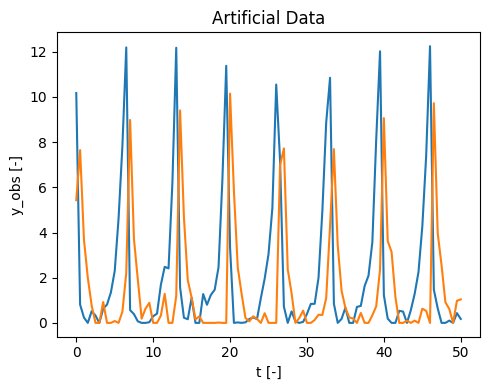

In [6]:
# Generate Lotka Volterra time series
sol = solve_ivp(lotkavolterra, (0, 50), np.array([10,5]), "LSODA", np.linspace(0,50,101), args=[1.3,0.9,0.8,1.8])

# Add "random" noise (example is made reproducible by setting a fixed seed)
rng = np.random.default_rng(seed=1)
noise = rng.normal(0, 0.5, (2,101))
y_obs = sol.y + noise
y_obs = np.greater(y_obs, np.zeros(y_obs.shape)) * y_obs

# Save the evaluated time points
t = sol.t

# Plot the generated data
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(t, y_obs.transpose(), label='Datapoints')
ax.set(xlabel='t [-]', ylabel='y_obs [-]', title ='Artificial Data')
plt.tight_layout()

# Create an xArray dataset containing the artificial data
data_obs_1 = xr.DataArray(y_obs[0], coords={"time": t}).to_dataset(name="prey")
data_obs_2 = xr.DataArray(y_obs[1], coords={"time": t}).to_dataset(name="predator")
data_obs = xr.merge([data_obs_1, data_obs_2])

# Add our dataset to the simulation
sim.observations = data_obs

# Pass the initial condition to the simulation
#
# Note: The input needs to be a list containing a separate string for every state variable.
#       Those strings must have the format "variableName=initialValue" (without any spaces!).
sim.config.simulation.y0 = ["prey=10", "predator=5"]

# Let parse_input() create an xArray dataset
#
# Note: The input variable drop_dims makes sure that the dataset only contains a single value
#       instead of a full time series filled with the same value over and over again.
y0_obs = sim.parse_input("y0", drop_dims=['time'])

# Add the initial condition to the simulation
sim.model_parameters["y0"] = y0_obs

In [7]:
# Parameterize the model
sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)

# Make sure the model parameters are available to the model
sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Look at the parameter values passed to the model
sim.model_parameters["parameters"]

{'alpha': 1.3, 'delta': 1.8}

In [8]:
sim.config.simulation.n_ode_states = 2

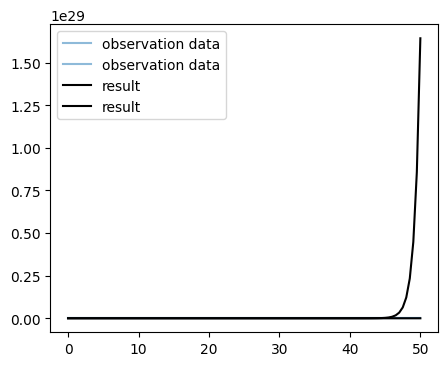

In [9]:
# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator, run the simulation and obtain the results
evaluator = sim.dispatch(theta={"delta":1.8})
evaluator()
data_res = evaluator.results

# Plot the results
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(data_obs.time, data_obs.prey, ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(data_obs.time, data_obs.predator, ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(data_res.time, data_res.prey, color="black", label ="result")
ax.plot(data_res.time, data_res.predator, color="black", label ="result")
ax.legend()